# Mycelium Performance Analysis

Latency (with crypto / transport / metadata phase breakdown) and storage overhead for
`PUT`, `GET` and `REPAIR` operations, from the benchmark CSV described in
[ADR-0007](../adr/0007-metrics-collector.md).

Data source: `benchmark_results.csv` if present, otherwise `sample_results.csv`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import metrics_utils as mu

pd.set_option("display.width", 120)

df = mu.load_metrics()
print(f"Loaded {len(df)} records")
df.groupby("operation").size().rename("records")

Loaded 1596 records


operation
GET       588
PUT       588
REPAIR    420
Name: records, dtype: int64

In [2]:
df.head()

,operation,k,m,shard_size,object_size,failed_nodes,total_nodes,crypto_ms,transport_ms,metadata_ms,total_ms,success,storage_overhead,code_rate,config_label,object_size_kb,failure_ratio
0,PUT,2,1,512,1024,0,4,0.183224,8.707630,2.617710,11.52890,1,1.60254,0.666667,2+1,1.0,0.0
1,GET,2,1,512,1024,0,3,0.113425,0.359385,0.851420,1.33009,1,0.00000,0.666667,2+1,1.0,0.0
2,PUT,2,1,2048,4096,0,4,0.182169,4.186460,2.305840,6.69444,1,1.52563,0.666667,2+1,4.0,0.0
3,GET,2,1,2048,4096,0,3,0.108873,0.490481,0.590589,1.19683,1,0.00000,0.666667,2+1,4.0,0.0
4,PUT,2,1,8192,16384,0,4,0.204716,5.056120,2.449290,7.73102,1,1.50641,0.666667,2+1,16.0,0.0


## 1. Total latency by operation

Mean total latency per operation, with standard deviation as error bars.

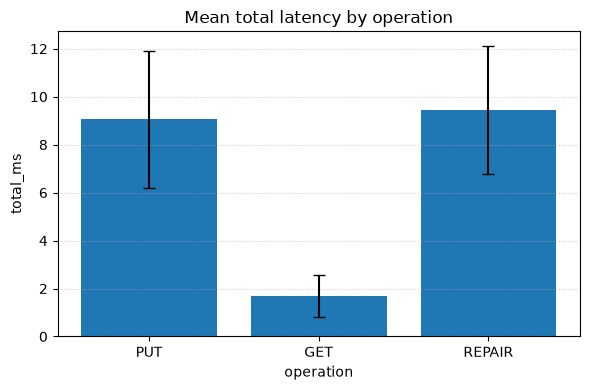

,operation,mean,std
0,PUT,9.063,2.856
1,GET,1.687,0.880
2,REPAIR,9.442,2.677


In [3]:
by_op = (
    df.groupby("operation")["total_ms"]
    .agg(["mean", "std"])
    .reindex([o for o in mu.OPERATIONS if o in df["operation"].unique()])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 4))
mu.bar(by_op, x="operation", y="mean", yerr="std",
       title="Mean total latency by operation", ylabel="total_ms", ax=ax)
plt.tight_layout()
plt.show()
by_op.round(3)

## 2. Phase breakdown: crypto vs transport vs metadata

How much of each operation's time is spent in the crypto phase, the
transport phase, and the metadata-store phase.

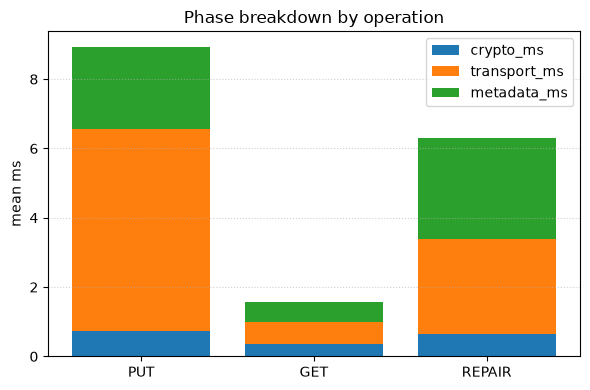

,crypto_ms,transport_ms,metadata_ms
operation,,,
PUT,0.734,5.842,2.357
GET,0.346,0.649,0.584
REPAIR,0.651,2.750,2.900


In [4]:
phases = (
    df.groupby("operation")[["crypto_ms", "transport_ms", "metadata_ms"]]
    .mean()
    .reindex([o for o in mu.OPERATIONS if o in df["operation"].unique()])
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(phases.index, phases["crypto_ms"], label="crypto_ms")
ax.bar(phases.index, phases["transport_ms"], bottom=phases["crypto_ms"],
       label="transport_ms")
ax.bar(phases.index, phases["metadata_ms"],
       bottom=phases["crypto_ms"] + phases["transport_ms"], label="metadata_ms")
ax.set_ylabel("mean ms")
ax.set_title("Phase breakdown by operation")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()
phases.round(3)

## 3. Latency vs object size

Total latency scaling with object size (log x-axis), one line per operation.

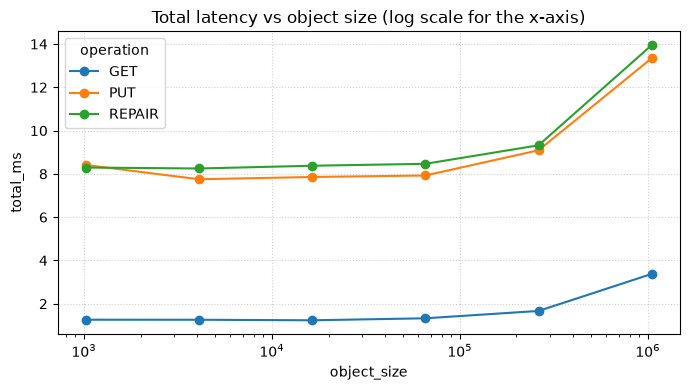

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
mu.line_by_group(df, x="object_size", y="total_ms", group="operation",
                 title="Total latency vs object size (log scale for the x-axis)", ylabel="total_ms",
                 logx=True, ax=ax)
plt.tight_layout()
plt.show()

## 4. Latency vs erasure parameters (k, m)

Mean total latency per `k+m` configuration, faceted by operation.

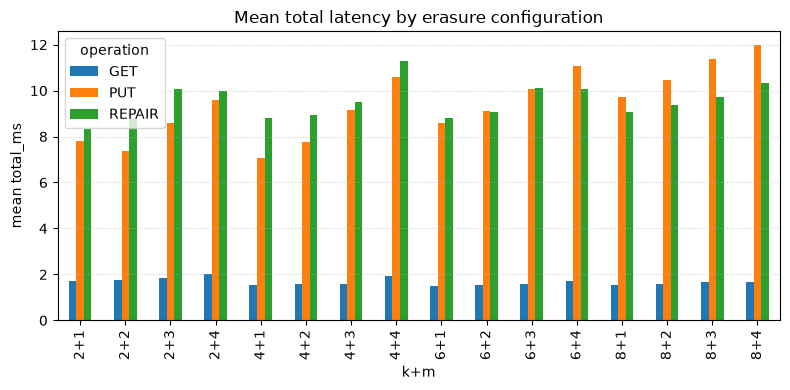

operation,GET,PUT,REPAIR
config_label,,,
2+1,1.711,7.789,8.308
2+2,1.771,7.390,8.791
2+3,1.861,8.576,10.082
2+4,2.003,9.573,9.995
4+1,1.524,7.072,8.806
4+2,1.564,7.755,8.926
4+3,1.596,9.148,9.505
4+4,1.945,10.609,11.277
6+1,1.517,8.574,8.817


In [6]:
config = (
    df.groupby(["operation", "config_label"])["total_ms"]
    .mean()
    .unstack("operation")
)

ax = config.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("mean total_ms")
ax.set_xlabel("k+m")
ax.set_title("Mean total latency by erasure configuration")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()
config.round(3)

## 5. Storage overhead

`storage_overhead` is the ratio of total serialized shard bytes to object
size, captured on `PUT` (it includes nonce, GCM tag and msgpack framing, so it
exceeds the theoretical `(k+m)/k` code rate).

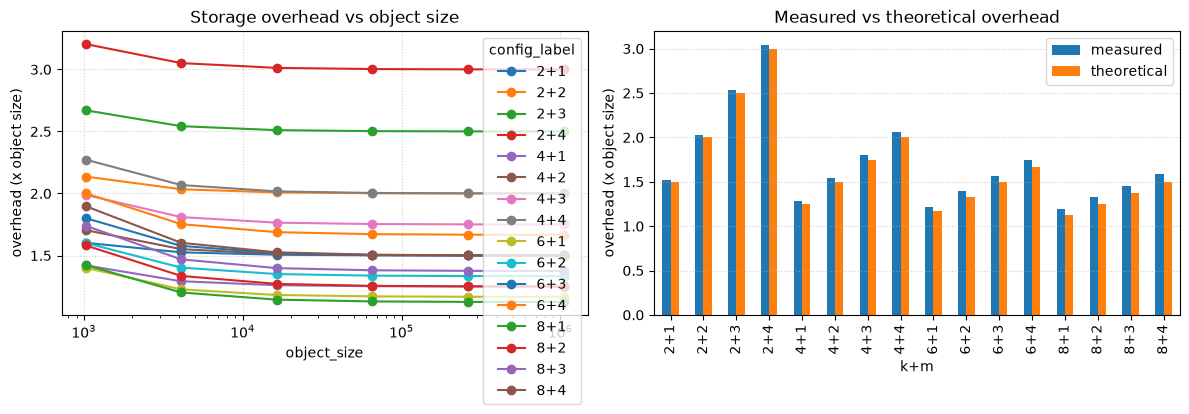

,measured,theoretical
config_label,,
2+1,1.523,1.5
2+2,2.030,2.0
2+3,2.538,2.5
2+4,3.046,3.0
4+1,1.288,1.25
4+2,1.546,1.5
4+3,1.803,1.75
4+4,2.061,2.0
6+1,1.219,1.167


In [7]:
puts = df[df["operation"] == "PUT"].copy()

if puts.empty:
    print("No PUT records available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Overhead vs object size, one line per configuration.
    mu.line_by_group(puts, x="object_size", y="storage_overhead",
                     group="config_label",
                     title="Storage overhead vs object size",
                     ylabel="overhead (x object size)", logx=True, ax=axes[0])

    # Overhead vs configuration: compare against the theoretical (k+m)/k rate.
    by_cfg = puts.groupby("config_label").agg(
        measured=("storage_overhead", "mean"),
        theoretical=("code_rate", lambda s: 1.0 / s.mean()),
    )
    by_cfg.plot(kind="bar", ax=axes[1])
    axes[1].set_ylabel("overhead (x object size)")
    axes[1].set_xlabel("k+m")
    axes[1].set_title("Measured vs theoretical overhead")
    axes[1].grid(axis="y", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()
    display(by_cfg.round(3))

## 6. Summary statistics

Distribution of latency phases per operation.

In [8]:
mu.summary_by(df, group_cols=["operation"],
              metric_cols=["crypto_ms", "transport_ms", "total_ms"])

crypto_ms                            transport_ms                             total_ms                \
               mean    std    min    max count         mean    std    min     max count     mean    std    min   
operation                                                                                                        
GET           0.346  0.444  0.095  2.685   588        0.649  0.305  0.262   3.004   588    1.687  0.880  0.861   
PUT           0.734  1.012  0.153  5.877   588        5.842  1.902  1.653  18.307   588    9.063  2.856  3.885   
REPAIR        0.651  1.093  0.040  4.790   420        2.750  1.044  1.721  11.151   420    9.442  2.677  5.579   

                         
              max count  
operation                
GET         6.087   588  
PUT        20.936   588  
REPAIR     24.880   420